# Assignment 12 – Titanic Data Visualization

Completed using **pandas** and **Matplotlib** with the provided `titanic_dataset.xlsx` file.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Titanic dataset
df = pd.read_excel("titanic_dataset.xlsx")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.

#### X-axis: Embarked
#### Y-axis: Average of Survived
#### Add proper title and labels.
#### Identify which port has the highest survival rate.

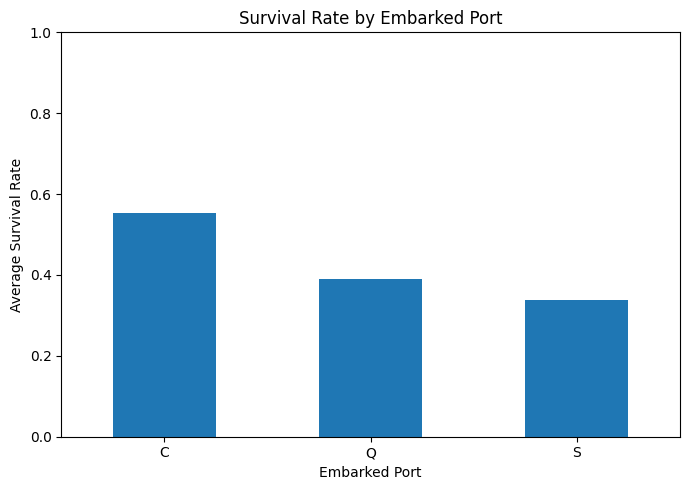

Survival rates by port:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

Highest survival rate: Port C (55.36%)


In [2]:
# Q1: Survival rate by Embarked port
survival_by_port = df.groupby("Embarked", dropna=True)["Survived"].mean()

ax = survival_by_port.plot(kind="bar", figsize=(7, 5))
ax.set_title("Survival Rate by Embarked Port")
ax.set_xlabel("Embarked Port")
ax.set_ylabel("Average Survival Rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

highest_port = survival_by_port.idxmax()
highest_rate = survival_by_port.max()

print("Survival rates by port:")
print(survival_by_port)
print(f"\nHighest survival rate: Port {highest_port} ({highest_rate:.2%})")


### Q2. Create a new column FamilySize using:

#### FamilySize = SibSp + Parch + 1

#### Then create a Count Plot showing the number of passengers for each family-size category.

#### X-axis: FamilySize
#### Y-axis: Number of Passengers
#### Identify the most common family size.

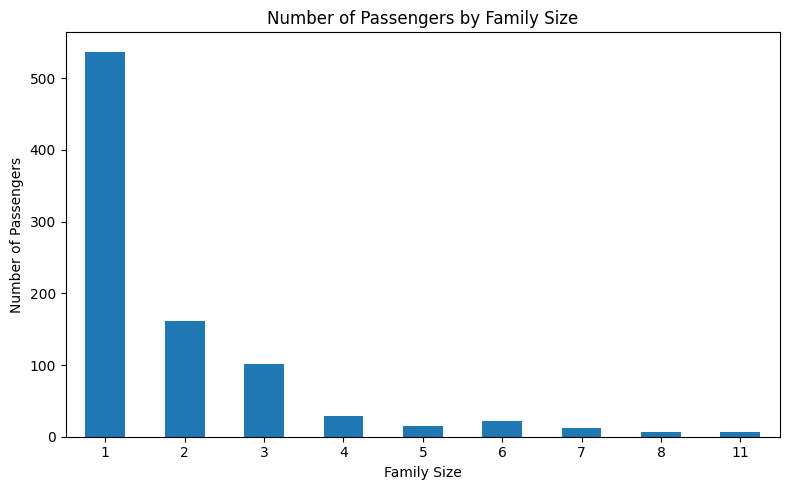

Most common family size: 1
Number of passengers: 537


In [3]:
# Q2: Create FamilySize and plot passenger counts
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_counts = df["FamilySize"].value_counts().sort_index()

ax = family_counts.plot(kind="bar", figsize=(8, 5))
ax.set_title("Number of Passengers by Family Size")
ax.set_xlabel("Family Size")
ax.set_ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

most_common_family = df["FamilySize"].mode().iloc[0]
most_common_count = family_counts.loc[most_common_family]

print(f"Most common family size: {most_common_family}")
print(f"Number of passengers: {most_common_count}")


### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

#### X-axis: Pclass
#### Y-axis: Fare
#### Use Sex as hue.
#### Identify which group paid the highest fares.

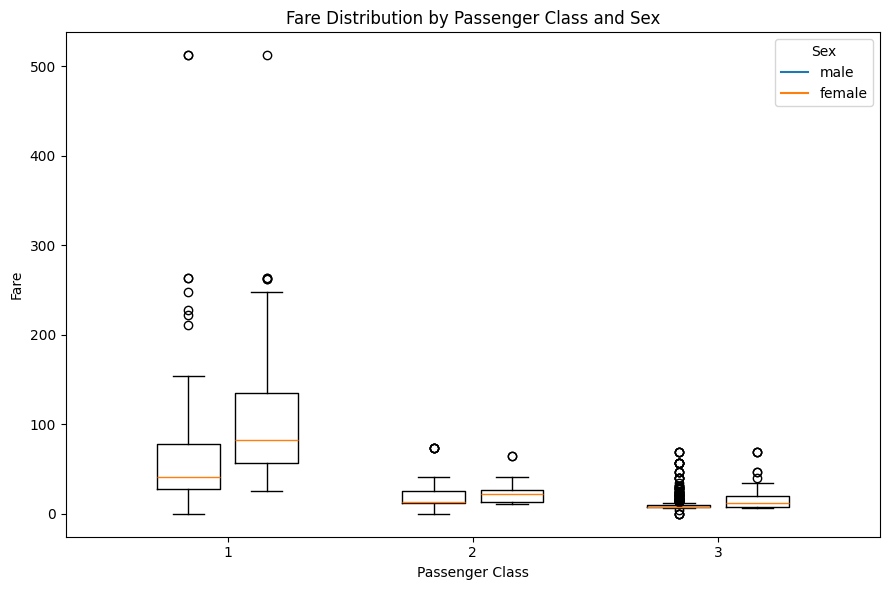

                     mean    median       max
Pclass Sex                                   
1      female  106.125798  82.66455  512.3292
       male     67.226127  41.26250  512.3292
2      female   21.970121  22.00000   65.0000
       male     19.741782  13.00000   73.5000
3      female   16.118810  12.47500   69.5500
       male     12.661633   7.92500   69.5500

Highest individual fare was paid in Pclass 1 by female passengers: 512.3292


In [4]:
# Q3: Box plot of Fare by Pclass, separated by Sex
classes = sorted(df["Pclass"].dropna().unique())
sexes = list(df["Sex"].dropna().unique())

positions = []
box_data = []
labels = []
width = 0.32

for pclass in classes:
    for j, sex in enumerate(sexes):
        vals = df.loc[(df["Pclass"] == pclass) & (df["Sex"] == sex), "Fare"].dropna()
        offset = (j - (len(sexes)-1)/2) * width
        positions.append(pclass + offset)
        box_data.append(vals)
        labels.append(f"{pclass}-{sex}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(box_data, positions=positions, widths=width*0.8, patch_artist=False)
ax.set_title("Fare Distribution by Passenger Class and Sex")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Fare")
ax.set_xticks(classes)
ax.set_xticklabels(classes)

# Create a simple legend using invisible plotted handles
for sex in sexes:
    ax.plot([], [], label=sex)
ax.legend(title="Sex")

plt.tight_layout()
plt.show()

fare_summary = df.groupby(["Pclass", "Sex"])["Fare"].agg(["mean", "median", "max"])
print(fare_summary)

max_group = fare_summary["max"].idxmax()
max_fare = fare_summary["max"].max()
print(f"\nHighest individual fare was paid in Pclass {max_group[0]} by {max_group[1]} passengers: {max_fare:.4f}")


### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

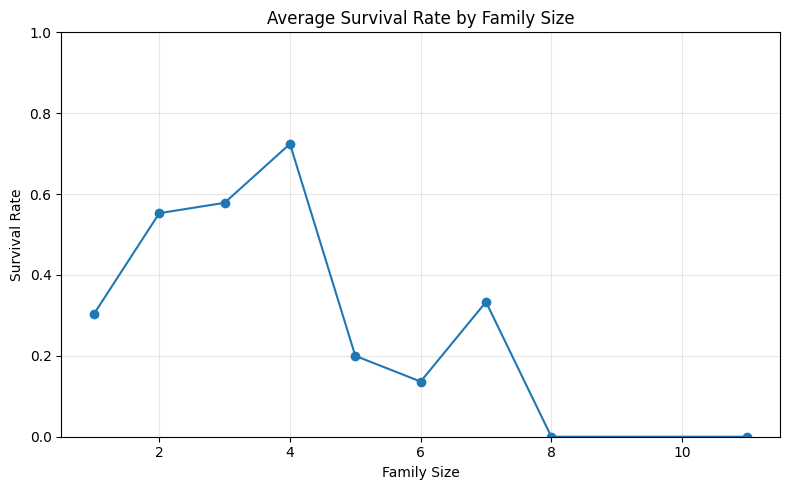

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Family size with highest survival rate: 4 (72.41%)


In [5]:
# Q4: Average survival rate by FamilySize
survival_by_family = df.groupby("FamilySize")["Survived"].mean().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(survival_by_family.index, survival_by_family.values, marker="o")
ax.set_title("Average Survival Rate by Family Size")
ax.set_xlabel("Family Size")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_family = survival_by_family.idxmax()
best_rate = survival_by_family.max()

print(survival_by_family)
print(f"\nFamily size with highest survival rate: {best_family} ({best_rate:.2%})")


### Q5.Passenger Class & Gender Survival Comparison
#### Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

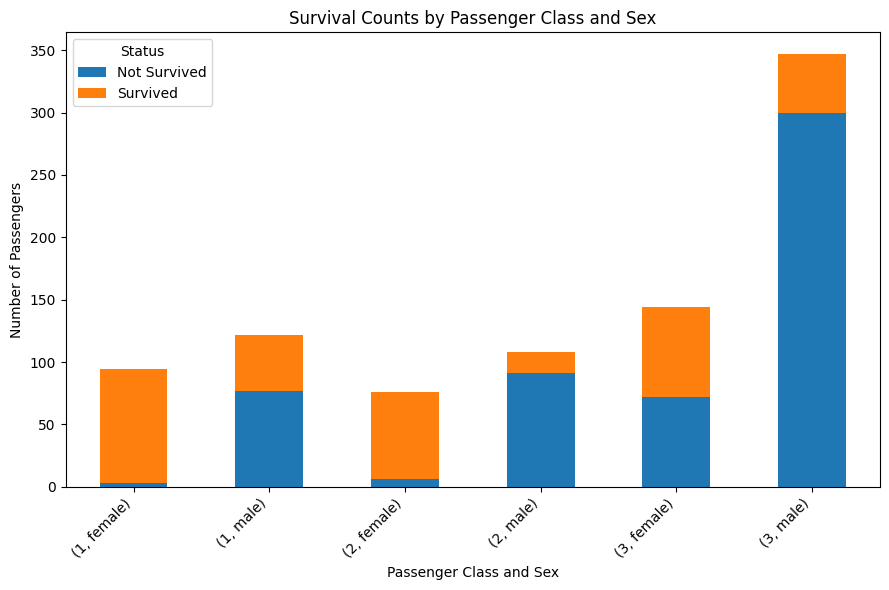

Survived       Not Survived  Survived
Pclass Sex                           
1      female             3        91
       male              77        45
2      female             6        70
       male              91        17
3      female            72        72
       male             300        47


In [6]:
# Q5: Stacked bar chart of survival by Pclass and Sex
survival_counts = (
    df.groupby(["Pclass", "Sex", "Survived"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "Not Survived", 1: "Survived"})
)

ax = survival_counts.plot(kind="bar", stacked=True, figsize=(9, 6))
ax.set_title("Survival Counts by Passenger Class and Sex")
ax.set_xlabel("Passenger Class and Sex")
ax.set_ylabel("Number of Passengers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

print(survival_counts)
